In [3]:
# Выполните один раз в терминале VS Code: pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Библиотеки загружены. Версия sklearn:", __import__('sklearn').__version__)

✅ Библиотеки загружены. Версия sklearn: 1.8.0


📂 Загружено: 10000 строк, 5 признаков
   amount  time   location    device  is_fraud
0   28.40   7.7     Москва  Смартфон         0
1   14.12   2.5     Москва        ПК         0
2   33.53   1.7  Зарубежье  Смартфон         0
3   87.82   2.3     Онлайн        ПК         0
4   12.71  14.0     Москва        ПК         0

📊 Распределение классов:
is_fraud
0    8916
1    1084
Name: count, dtype: int64
Доля мошенничества: 10.84%


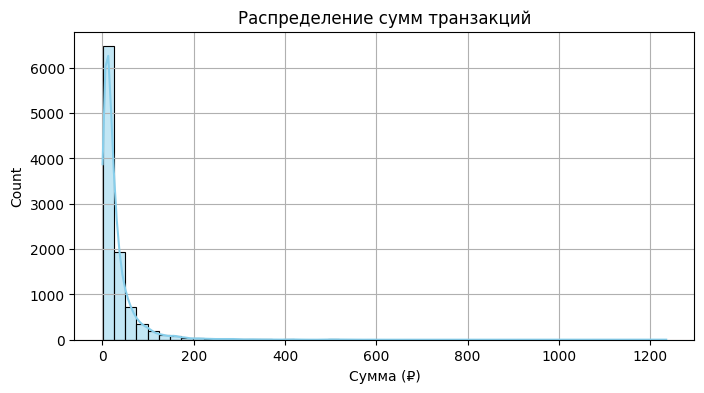

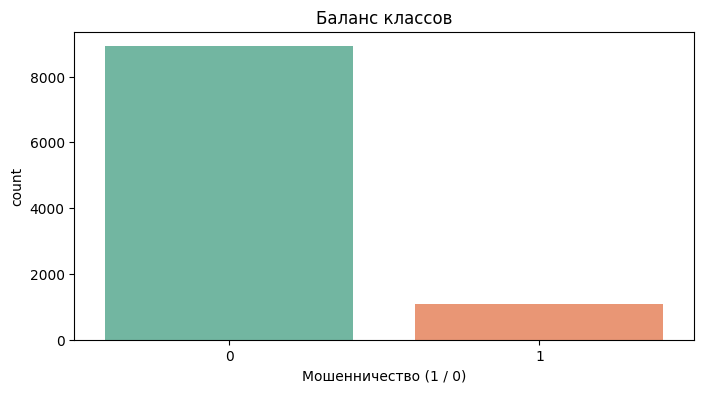

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Загрузка готового CSV
df = pd.read_csv("fraud_data.csv")

print(f"📂 Загружено: {df.shape[0]} строк, {df.shape[1]} признаков")
print(df.head())
print("\n📊 Распределение классов:")
print(df['is_fraud'].value_counts())
print(f"Доля мошенничества: {df['is_fraud'].mean():.2%}")

# Визуализация распределения
plt.figure(figsize=(8,4))
sns.histplot(df['amount'], bins=50, kde=True, color='skyblue')
plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма (₽)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='is_fraud', data=df, palette='Set2')
plt.title('Баланс классов')
plt.xlabel('Мошенничество (1 / 0)')
plt.show()

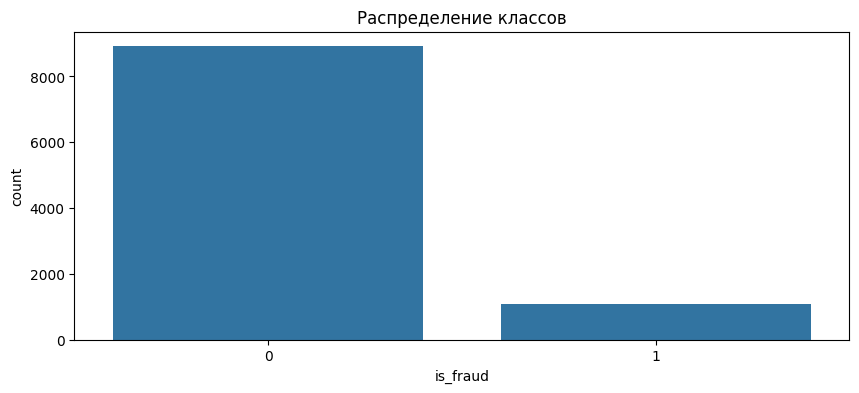

In [5]:
plt.figure(figsize=(10,4))
sns.countplot(x='is_fraud', data=df)
plt.title('Распределение классов')
plt.show()

# Кодирование категориальных признаков
le_loc = LabelEncoder()
le_dev = LabelEncoder()
df['location_enc'] = le_loc.fit_transform(df['location'])
df['device_enc'] = le_dev.fit_transform(df['device'])

X = df[['amount', 'time', 'location_enc', 'device_enc']]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Precision': classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'Recall': classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    }
    print(f"\n🔹 {name}")
    print(classification_report(y_test, y_pred))

# Выбор лучшей модели
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
print(f"\n🏆 Лучшая модель по ROC-AUC: {best_name}")
print(pd.DataFrame(results).round(4))

os.makedirs("models", exist_ok=True)

# Сохранение артефактов
joblib.dump({
    'model': models[best_name],
    'scaler': scaler,
    'le_loc': le_loc,
    'le_dev': le_dev,
    'metrics': results[best_name]
}, 'models/fraud_model.pkl')
print("💾 Модель и препроцессоры сохранены в models/fraud_model.pkl")


🔹 Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.54      0.68      1783
           1       0.13      0.55      0.21       217

    accuracy                           0.54      2000
   macro avg       0.52      0.55      0.44      2000
weighted avg       0.82      0.54      0.63      2000


🔹 Random Forest
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1783
           1       0.12      0.01      0.02       217

    accuracy                           0.88      2000
   macro avg       0.51      0.50      0.48      2000
weighted avg       0.81      0.88      0.84      2000


🔹 Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1783
           1       0.25      0.01      0.02       217

    accuracy                           0.89      2000
   macro avg       0.57      0.50      0.48      2000
weighted avg 

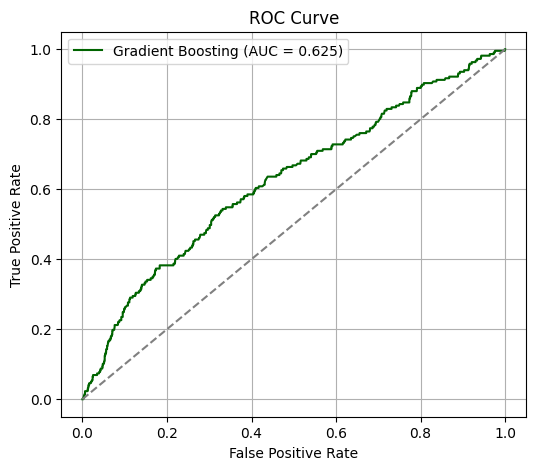

In [8]:
best_model = models[best_name]
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_name} (AUC = {roc_auc_score(y_test, y_prob):.3f})', color='darkgreen')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()